In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import json
from pathlib import Path
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

print("CUDA :", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Устройство:", device)

CUDA : False
Устройство: cpu


In [72]:
notebook_path = Path.cwd()  
dataset_path = notebook_path / 'data' / 'processed' / 'swans_dataset'
info_path = dataset_path / 'dataset_info.json'

with open(info_path, 'r', encoding='utf-8') as f:
    dataset_info = json.load(f)

for species_key, info in dataset_info['species_info'].items():
    count = dataset_info['species_counts'].get(species_key, 0)
    print(f"{info['common_name_ru']} ({info['latin_name']}): {count} изображений")


Лебедь-шипун (Cygnus olor): 50 изображений
Чёрный лебедь (Cygnus atratus): 50 изображений
Лебедь-кликун (Cygnus cygnus): 50 изображений
Черношейный Лебедь (Cygnus melancoryphus): 50 изображений
Лебедь-Трубач (Cygnus buccinator): 50 изображений
Американский Лебедь (Cygnus columbianus): 50 изображений


In [73]:
# mapping видов
species_names = list(dataset_info['species_info'].keys())
species_names_ru = [dataset_info['species_info'][cls]['common_name_ru'] for cls in species_names]
num_species = len(species_names)

class SwanDataset(Dataset):
    
    def __init__(self, subset='train', transform=None):
        self.subset = subset
        self.transform = transform
        self.data_dir = dataset_path / subset

        metadata_path = dataset_path / f'{subset}_metadata.csv'
        self.metadata = pd.read_csv(metadata_path, encoding='utf-8')

        self.species_to_idx = {cls: idx for idx, cls in enumerate(species_names)}
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = self.data_dir / row['species_key'] / row['filename']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.species_to_idx[row['species_key']]
        
        return image, label, str(img_path)

In [74]:
from torchvision import transforms as T

# Трансформации для train (с аугментацией)
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Разный масштаб
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),  # Вертикальное отражение
    T.RandomRotation(30),  # Увеличим угол
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Сдвиг
    T.RandomPerspective(distortion_scale=0.2, p=0.5),  # Перспектива
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.3, scale=(0.02, 0.2)),  # Random Erasing
])
# Трансформации для val/test (без аугментации)
val_transform = T.Compose([
    T.Resize((224, 224)),  
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = SwanDataset('train', transform=train_transform)
val_dataset = SwanDataset('val', transform=val_transform)
test_dataset = SwanDataset('test', transform=val_transform)


In [75]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0  
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [76]:
class SwanClassifier(nn.Module):
    
    def __init__(self, num_classes=6, model_name='resnet18', dropout_rate=0.3, freeze_backbone=False):
        super().__init__()
        self.model_name = model_name
        
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            
            # Замораживаем бэкбон если нужно
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            in_features = self.backbone.fc.in_features
            
            # Заменяем финальный слой с улучшенной архитектурой
            self.backbone.fc = nn.Sequential(
                nn.Dropout(dropout_rate),
                nn.Linear(in_features, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(dropout_rate/2),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(dropout_rate/3),
                nn.Linear(256, num_classes)
            )
            
        elif model_name == 'mobilenet_v2':
            self.backbone = models.mobilenet_v2(pretrained=True)
            
            # Замораживаем бэкбон если нужно
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            in_features = self.backbone.classifier[1].in_features
            
            # Правильно заменяем classifier для MobileNet
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(dropout_rate),
                nn.Linear(in_features, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(dropout_rate/2),
                nn.Linear(512, num_classes)
            )
            
        elif model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
            
            # Замораживаем бэкбон если нужно
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            in_features = self.backbone.classifier[1].in_features
            
            # Правильно заменяем classifier для EfficientNet
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(dropout_rate),
                nn.Linear(in_features, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(dropout_rate/2),
                nn.Linear(512, num_classes)
            )
        
        else:
            raise ValueError(f"Модель {model_name} не поддерживается")
    
    def forward(self, x):
        return self.backbone(x)
    
    def unfreeze_backbone(self, unfreeze_all=False):
        """Размораживает слои бэкбона"""
        print(f"Размораживаем {self.model_name}...")
        
        if self.model_name == 'resnet18':
            if unfreeze_all:
                # Размораживаем всё
                for param in self.backbone.parameters():
                    param.requires_grad = True
            else:
                # Размораживаем только последние слои
                # layer4 - последний блок ResNet
                for param in self.backbone.layer4.parameters():
                    param.requires_grad = True
                # layer3 - предпоследний блок
                for param in self.backbone.layer3.parameters():
                    param.requires_grad = True
        
        elif self.model_name in ['mobilenet_v2', 'efficientnet_b0']:
            # Для этих моделей размораживаем все параметры
            for param in self.backbone.parameters():
                param.requires_grad = True
    
    def freeze_backbone(self):
        """Замораживает все слои бэкбона"""
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Классификатор всегда остается размороженным
        if self.model_name == 'resnet18':
            for param in self.backbone.fc.parameters():
                param.requires_grad = True
        else:
            for param in self.backbone.classifier.parameters():
                param.requires_grad = True
    

model = SwanClassifier(
    num_classes=6,
    model_name='resnet18',
    dropout_rate=0.7, 
    freeze_backbone=True
)
model = model.to(device)

print(model)

SwanClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [77]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels, _) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Прогресс
        if (batch_idx + 1) % 5 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    
    return val_loss, val_acc, all_preds, all_labels

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(train_losses, label='Train Loss', marker='o')
    axes[0].plot(val_losses, label='Val Loss', marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss during Training')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(train_accs, label='Train Accuracy', marker='o')
    axes[1].plot(val_accs, label='Val Accuracy', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy during Training')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

🚀 Начинаем обучение...
   Эпох: 20
   Learning rate: 0.001
   Batch size: 32
   Устройство: cpu

Epoch 1/20
  Batch [5/7], Loss: 2.0652
Train Loss: 1.9828, Train Acc: 12.38%
Val Loss: 1.7454, Val Acc: 22.22%

Epoch 2/20
  Batch [5/7], Loss: 1.6767
Train Loss: 1.8831, Train Acc: 24.76%
Val Loss: 1.6905, Val Acc: 35.56%

Epoch 3/20
  Batch [5/7], Loss: 1.8962
Train Loss: 1.8200, Train Acc: 29.52%
Val Loss: 1.6141, Val Acc: 48.89%

Epoch 4/20
  Batch [5/7], Loss: 1.5730
Train Loss: 1.7643, Train Acc: 26.19%
Val Loss: 1.5749, Val Acc: 46.67%

Epoch 5/20
  Batch [5/7], Loss: 1.6855
Train Loss: 1.7279, Train Acc: 30.00%
Val Loss: 1.5456, Val Acc: 44.44%

Epoch 6/20
  Batch [5/7], Loss: 1.8034
Train Loss: 1.8079, Train Acc: 24.29%
Val Loss: 1.5516, Val Acc: 46.67%

Epoch 7/20
  Batch [5/7], Loss: 1.4613
Train Loss: 1.6755, Train Acc: 33.33%
Val Loss: 1.5364, Val Acc: 46.67%

Epoch 8/20
  Batch [5/7], Loss: 1.7056
Train Loss: 1.6091, Train Acc: 36.67%
Val Loss: 1.5341, Val Acc: 48.89%

Epoch 9

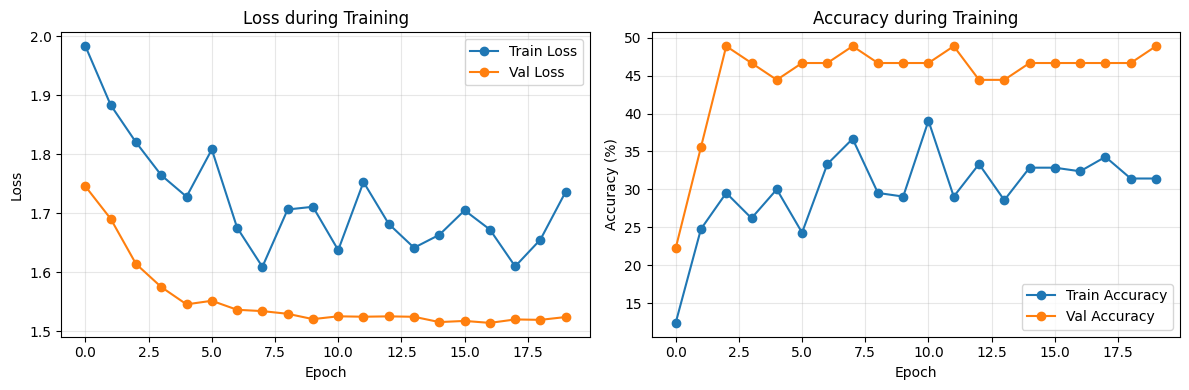

In [78]:
# Параметры обучения
epochs = 20
learning_rate = 0.001

# Loss function и optimizer
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Scheduler для уменьшения learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"🚀 Начинаем обучение...")
print(f"   Эпох: {epochs}")
print(f"   Learning rate: {learning_rate}")
print(f"   Batch size: {batch_size}")
print(f"   Устройство: {device}")

# Для хранения истории
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{epochs}")
    
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Обновляем scheduler
    scheduler.step()

    patience = 5
    no_improve = 0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        # Сохраняем модель
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping на эпохе {epoch+1}")
            break

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'train_loss': train_loss,
        }, '../models/best_swan_model.pth')
        print(f"💾 Сохранена лучшая модель с точностью {val_acc:.2f}%")

print(f"\n✅ Обучение завершено!")
print(f"   Лучшая точность на валидации: {best_val_acc:.2f}%")

# Визуализируем историю обучения
plot_training_history(train_losses, val_losses, train_accs, val_accs)

In [79]:
# # Загружаем лучшую модель
# checkpoint = torch.load('../models/best_swan_model.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

# print(f"📦 Загружена лучшая модель (точность: {checkpoint['val_acc']:.2f}%)")

# # Тестируем на test данных
# test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)

# print(f"\n📊 РЕЗУЛЬТАТЫ НА ТЕСТЕ:")
# print(f"   Test Loss: {test_loss:.4f}")
# print(f"   Test Accuracy: {test_acc:.2f}%")
# print(f"   Правильно классифицировано: {int(test_acc/100 * len(test_dataset))}/{len(test_dataset)}")

# # Confusion matrix
# cm = confusion_matrix(test_labels, test_preds)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_names_ru,
#             yticklabels=class_names_ru)
# plt.title('Confusion Matrix - Test Set')
# plt.xlabel('Предсказанные метки')
# plt.ylabel('Истинные метки')
# plt.tight_layout()
# plt.show()

# # Classification report
# print("\n📋 Classification Report:")
# print(classification_report(test_labels, test_preds, 
#                            target_names=class_names_ru,
#                            zero_division=0))

In [80]:
# def analyze_errors(model, test_loader, device):
#     """Анализирует ошибки классификации"""
#     model.eval()
#     errors = []
    
#     with torch.no_grad():
#         for images, labels, paths in test_loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, preds = outputs.max(1)
            
#             for i in range(len(labels)):
#                 if preds[i] != labels[i]:
#                     errors.append({
#                         'image_path': paths[i],
#                         'true_label': class_names_ru[labels[i].item()],
#                         'predicted_label': class_names_ru[preds[i].item()],
#                         'true_class_idx': labels[i].item(),
#                         'pred_class_idx': preds[i].item()
#                     })
    
#     return errors

# # Получаем ошибки
# errors = analyze_errors(model, test_loader, device)

# print(f"\n🔍 АНАЛИЗ ОШИБОК:")
# print(f"   Всего ошибок: {len(errors)}/{len(test_dataset)} ({len(errors)/len(test_dataset)*100:.1f}%)")

# if errors:
#     print(f"\n📋 Примеры ошибок:")
#     for i, error in enumerate(errors[:3]):  # Показываем первые 3
#         print(f"\n  Ошибка {i+1}:")
#         print(f"    Изображение: {Path(error['image_path']).name}")
#         print(f"    Истинный класс: {error['true_label']}")
#         print(f"    Предсказанный класс: {error['predicted_label']}")
    
#     # Визуализируем ошибки
#     fig, axes = plt.subplots(1, min(3, len(errors)), figsize=(15, 5))
#     if len(errors) == 1:
#         axes = [axes]
    
#     for idx, (ax, error) in enumerate(zip(axes, errors[:3])):
#         img_path = error['image_path']
#         image = Image.open(img_path).convert('RGB')
        
#         ax.imshow(image)
#         ax.set_title(f"Истинный: {error['true_label']}\nПредсказанный: {error['predicted_label']}")
#         ax.axis('off')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("🎉 Нет ошибок на тестовых данных!")

In [81]:
# # Сохраняем финальную модель
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'class_names': class_names,
#     'class_names_ru': class_names_ru,
#     'num_classes': num_classes,
#     'test_accuracy': test_acc,
#     'dataset_info': dataset_info,
#     'transform': val_transform
# }, '../models/final_swan_model.pth')

# print(f"💾 Финальная модель сохранена в ../models/final_swan_model.pth")

# # Сохраняем результаты эксперимента
# results = {
#     'train_accuracy': train_accs[-1],
#     'val_accuracy': val_accs[-1],
#     'test_accuracy': test_acc,
#     'best_val_accuracy': best_val_acc,
#     'epochs': epochs,
#     'batch_size': batch_size,
#     'learning_rate': learning_rate,
#     'model_architecture': 'ResNet18',
#     'num_trainable_params': trainable_params,
#     'num_total_params': total_params,
#     'errors_count': len(errors),
#     'confusion_matrix': cm.tolist(),
#     'timestamp': pd.Timestamp.now().isoformat()
# }

# results_path = Path('../metrics/training_results.json')
# results_path.parent.mkdir(exist_ok=True)

# with open(results_path, 'w', encoding='utf-8') as f:
#     json.dump(results, f, indent=2)

# print(f"📊 Результаты сохранены в {results_path}")

# # Создаём отчёт
# report = f"""
# # Отчёт по обучению модели классификации лебедей

# ## Общая информация
# - Датасет: {dataset_info['total_images']} изображений, {dataset_info['species_count']} видов
# - Дата обучения: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
# - Устройство: {device}

# ## Результаты
# - **Точность на train: {train_accs[-1]:.2f}%**
# - **Точность на val: {val_accs[-1]:.2f}%**
# - **Точность на test: {test_acc:.2f}%**
# - Лучшая точность на val: {best_val_acc:.2f}%
# - Количество ошибок на тесте: {len(errors)}/{len(test_dataset)}

# ## Параметры обучения
# - Эпохи: {epochs}
# - Batch size: {batch_size}
# - Learning rate: {learning_rate}
# - Архитектура: ResNet18
# - Обучаемых параметров: {trainable_params:,}

# ## Виды лебедей:
# {chr(10).join([f'- {info["common_name_ru"]} ({info["latin_name"]})' for info in dataset_info['species_info'].values()])}
# """

# print(report)

# # Сохраняем отчёт
# with open('../metrics/training_report.md', 'w', encoding='utf-8') as f:
#     f.write(report)

# print("📝 Отчёт сохранён в ../metrics/training_report.md")